In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print(f"PyTorch: {torch.__version__}")
print(f"pandas:  {pd.__version__}  (Monatsende-Alias hier: 'M')")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device:  {device}")

PyTorch: 2.4.1
pandas:  2.1.4  (Monatsende-Alias hier: 'M')
Device:  cpu


In [2]:
# AirPassengers Datensatz (1949-1960, monatlich) — identisch zum Hauptnotebook
air_passengers = [
    112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118,  # 1949
    115, 126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140,  # 1950
    145, 150, 178, 163, 172, 178, 199, 199, 184, 162, 146, 166,  # 1951
    171, 180, 193, 181, 183, 218, 230, 242, 209, 191, 172, 194,  # 1952
    196, 196, 236, 235, 229, 243, 264, 272, 237, 211, 180, 201,  # 1953
    204, 188, 235, 227, 234, 264, 302, 293, 259, 229, 203, 229,  # 1954
    242, 233, 267, 269, 270, 315, 364, 347, 312, 274, 237, 278,  # 1955
    284, 277, 317, 313, 318, 374, 413, 405, 355, 306, 271, 306,  # 1956
    315, 301, 356, 348, 355, 422, 465, 467, 404, 347, 305, 336,  # 1957
    340, 318, 362, 348, 363, 435, 491, 505, 404, 359, 310, 337,  # 1958
    360, 342, 406, 396, 420, 472, 548, 559, 463, 407, 362, 405,  # 1959
    417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390, 432,  # 1960
]

dates = pd.date_range(start='1949-01', periods=len(air_passengers), freq='M')
ts = pd.Series(air_passengers, index=dates, name='Passagiere (Tsd.)')

n_pred   = 12
ts_train = ts[:-n_pred]
ts_test  = ts[-n_pred:]
forecast_dates = ts_test.index
y_true = ts_test.values

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"Trainingsdaten: {len(ts_train)} Monate | Prognose-Horizont: {n_pred} Monate")

Trainingsdaten: 132 Monate | Prognose-Horizont: 12 Monate


In [3]:
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

MODEL = "Salesforce/moirai-1.1-R-base"
PDT   = n_pred         # Prognose-Horizont
CTX   = len(ts_train)  # Kontext-Laenge
PSZ   = "auto"         # Patch-Größe (auto = adaptiv je nach Frequenz)
BSZ   = 100            # Anzahl Monte-Carlo-Samples

model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(MODEL),
    prediction_length=PDT,
    context_length=CTX,
    patch_size=PSZ,
    num_samples=BSZ,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

predictor = model.create_predictor(batch_size=BSZ)
print(f"Moirai geladen: {MODEL}")

Moirai geladen: Salesforce/moirai-1.1-R-base


Moirai MAPE: 4.6%


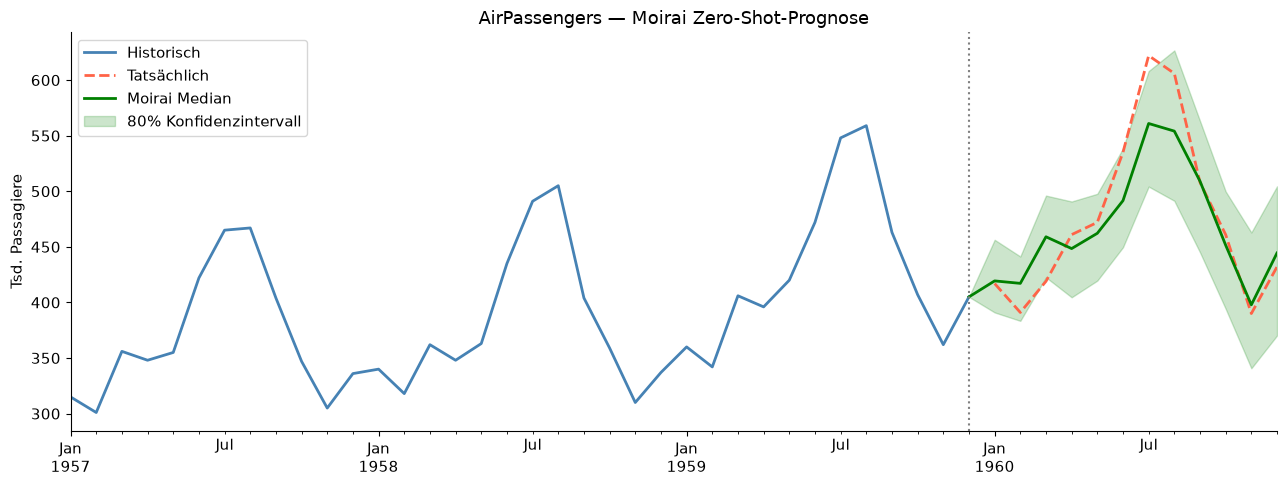

In [4]:
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

# Moirai erwartet die Daten im GluonTS-Format
ds = PandasDataset(dict(target=ts), freq="M")   # 'M' für pandas 2.1.x

train_data, test_gen = split(ds, offset=-n_pred)
test_data = test_gen.generate_instances(prediction_length=n_pred)

forecasts_moirai = list(predictor.predict(train_data))

fc_moirai = forecasts_moirai[0]
low_m  = np.quantile(fc_moirai.samples, 0.1, axis=0)
mid_m  = np.quantile(fc_moirai.samples, 0.5, axis=0)   # Median
high_m = np.quantile(fc_moirai.samples, 0.9, axis=0)

print(f"Moirai MAPE: {mape(y_true, mid_m):.1f}%")

# Visualisierung
fig, ax = plt.subplots(figsize=(13, 5))
ts_train[-36:].plot(ax=ax, color='steelblue', linewidth=2, label='Historisch')
ts_test.plot(ax=ax, color='tomato', linewidth=2, linestyle='--', label='Tatsächlich')
_hx, _hy = ax.lines[0].get_xdata(), ax.lines[0].get_ydata()
cx   = np.concatenate([[_hx[-1]], ax.lines[-1].get_xdata()])
conn = lambda y: np.concatenate([[_hy[-1]], y])
ax.plot(cx, conn(mid_m), color='green', linewidth=2, label='Moirai Median')
ax.fill_between(cx, conn(low_m), conn(high_m), alpha=0.2, color='green', label='80% Konfidenzintervall')
ax.axvline(ts_train.index[-1], color='gray', linestyle=':', linewidth=1.5)
ax.set_title('AirPassengers — Moirai Zero-Shot-Prognose', fontsize=13)
ax.set_ylabel('Tsd. Passagiere')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()